# Описание проекта: Определение возраста покупателей

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- Контролировать добросовестность кассиров при продаже алкоголя.

Постройте модель, которая по фотографии определит приблизительный возраст человека. В вашем распоряжении набор фотографий людей с указанием возраста.

## Исследовательский анализ данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50

In [ ]:
RANDOM_STATE = 57
VAL_SPLIT = 0.25

In [3]:
labels = pd.read_csv('/datasets/faces/labels.csv')
train_datagen = ImageDataGenerator(rescale=1./255)
train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=RANDOM_STATE) 

Found 7591 validated image filenames.


Выборка для обучения имеет 7591 изображение

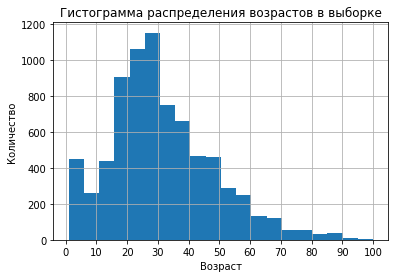

In [18]:
labels.hist(bins=20)
plt.title('Гистограмма распределения возрастов в выборке')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.xticks(range(0,110,10))
plt.show()

Согласно гистограмме видно, что в основном представлены возраста от 15 до 40 лет. В меньшей степени представлены от 0 до 15 и от 40 до 100 лет

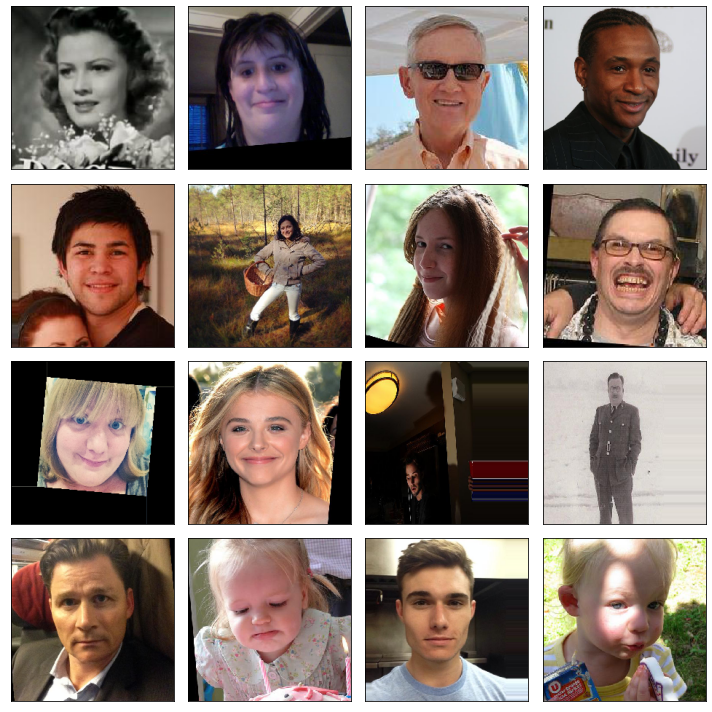

In [8]:
# выводим 16 изображений
features, target = next(train_gen_flow)
fig = plt.figure(figsize=(10,10))
for i in range(16):
    fig.add_subplot(4, 4, i+1)
    plt.imshow(features[i])
    # для компактности удаляем оси и прижимаем изображения друг к другу
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

### Вывод.
Из-за дисбаланса возрастов скорее всего модель будет лучше справляться с возрастами от 15 до 40 лет. А хуже всего будет справляться с возрастом от 60 до 100 лет, так как данных фотографий меньше всего.

При этом изображения в выборке достаточно четкие. Но есть и неудачные экземпляры, где лицо человека почти незаметно, скорее всего модель будет стараться опираться на общие очертания и постановку кадра в таких снимках, то есть кадр поставленный так же как старая фотография, может помечаться соответствующе

## Обучение модели

In [ ]:
def load_train(path='/datasets/faces/final_files/', batch_size=32, target_size=(224, 224), seed=RANDOM_STATE):
    labels = pd.read_csv(f'{path}/labels.csv')
    print("Количество строк в labels.csv:", len(labels))
    print("Первые 5 строк:", labels.head())
    train_datagen = ImageDataGenerator(
        validation_split=VAL_SPLIT,
        rescale=1./255,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=f'{path}/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=target_size,
        batch_size=batch_size,
        subset='training',
        class_mode='raw',
        seed=RANDOM_STATE)

    return train_gen_flow


def load_test(path='/datasets/faces/final_files/', batch_size=32, target_size=(224, 224), seed=RANDOM_STATE):
    labels = pd.read_csv(f'{path}/labels.csv')
    test_datagen = ImageDataGenerator(
        validation_split=VAL_SPLIT,
        rescale=1./255,
    )
    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=f'{path}/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=target_size,
        batch_size=batch_size,
        subset='validation',
        class_mode='raw',
        seed=RANDOM_STATE)

    return test_gen_flow


def create_model(input_shape):
    optimizer = Adam(learning_rate=0.0001)
    backbone = ResNet50(input_shape=(224, 224, 3),
                        weights='/datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
                        include_top=False)

    backbone.trainable = True

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='linear'))

    model.compile(optimizer=optimizer, loss='mean_squared_error',
                  metrics=['mae'])
    return model


def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            'best_model.h5', save_best_only=True, monitor='val_loss', mode='min'),
        tf.keras.callbacks.EarlyStopping(
            patience=10, restore_best_weights=True, monitor='val_loss'),
        tf.keras.callbacks.ReduceLROnPlateau(
            factor=0.5, patience=5, min_lr=1e-6, monitor='val_loss')
    ]
    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2, callbacks=callbacks)

    return model

### Результаты обучения модели

In [ ]:
2026-06-30 16:09:15.502592: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libnvinfer.so.6
# 2026-06-30 16:09:15.505483: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libnvinfer_plugin.so.6
# 2026-06-30 16:09:16.363435: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcuda.so.1
# 2026-06-30 16:09:16.407724: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1555] Found device 0 with properties: 
# pciBusID: 0000:81:00.0 name: Tesla V100-SXM2-32GB computeCapability: 7.0
# coreClock: 1.53GHz coreCount: 80 deviceMemorySize: 31.74GiB deviceMemoryBandwidth: 836.37GiB/s
# 2026-06-30 16:09:16.407858: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudart.so.10.1
# 2026-06-30 16:09:16.407969: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
# 2026-06-30 16:09:16.410415: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcufft.so.10
# 2026-06-30 16:09:16.410957: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcurand.so.10
# 2026-06-30 16:09:16.413947: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusolver.so.10
# 2026-06-30 16:09:16.415418: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusparse.so.10
# 2026-06-30 16:09:16.415518: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
# 2026-06-30 16:09:16.416779: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1697] Adding visible gpu devices: 0
# Using TensorFlow backend.
# Количество строк в labels.csv: 7591
# Первые 5 строк:     file_name  real_age
# 0  000000.jpg         4
# 1  000001.jpg        18
# 2  000002.jpg        80
# 3  000003.jpg        50
# 4  000004.jpg        17
# Found 5694 validated image filenames.
# Found 1897 validated image filenames.
# 2026-06-30 16:09:16.707559: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 AVX512F FMA
# 2026-06-30 16:09:16.714510: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 2099990000 Hz
# 2026-06-30 16:09:16.715154: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x5c9efc0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
# 2026-06-30 16:09:16.715217: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
# 2026-06-30 16:09:16.825856: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x57521a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
# 2026-06-30 16:09:16.825928: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100-SXM2-32GB, Compute Capability 7.0
# 2026-06-30 16:09:16.826684: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1555] Found device 0 with properties: 
# pciBusID: 0000:81:00.0 name: Tesla V100-SXM2-32GB computeCapability: 7.0
# coreClock: 1.53GHz coreCount: 80 deviceMemorySize: 31.74GiB deviceMemoryBandwidth: 836.37GiB/s
# 2026-06-30 16:09:16.826770: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudart.so.10.1
# 2026-06-30 16:09:16.826816: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
# 2026-06-30 16:09:16.826867: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcufft.so.10
# 2026-06-30 16:09:16.826911: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcurand.so.10
# 2026-06-30 16:09:16.826946: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusolver.so.10
# 2026-06-30 16:09:16.826981: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcusparse.so.10
# 2026-06-30 16:09:16.827010: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
# 2026-06-30 16:09:16.828063: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1697] Adding visible gpu devices: 0
# 2026-06-30 16:09:16.828152: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudart.so.10.1
# 2026-06-30 16:09:17.163990: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1096] Device interconnect StreamExecutor with strength 1 edge matrix:
# 2026-06-30 16:09:17.164066: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1102]      0 
# 2026-06-30 16:09:17.164108: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1115] 0:   N 
# 2026-06-30 16:09:17.165404: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:39] Overriding allow_growth setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
# 2026-06-30 16:09:17.165503: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1241] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 10240 MB memory) -> physical GPU (device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:81:00.0, compute capability: 7.0)
# <class 'tensorflow.python.keras.engine.sequential.Sequential'>
# WARNING:tensorflow:sample_weight modes were coerced from
#   ...
#     to  
#   ['...']
# WARNING:tensorflow:sample_weight modes were coerced from
#   ...
#     to  
#   ['...']
# Train for 178 steps, validate for 30 steps
# Epoch 1/20
# 2026-06-30 16:09:32.198110: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
# 2026-06-30 16:09:32.665324: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
# 178/178 - 111s - loss: 216.0559 - mae: 10.9417 - val_loss: 545.0188 - val_mae: 18.2856
# Epoch 2/20
# 178/178 - 94s - loss: 111.8404 - mae: 8.0328 - val_loss: 329.0229 - val_mae: 13.4325
# Epoch 3/20
# 178/178 - 92s - loss: 85.4084 - mae: 7.0887 - val_loss: 344.5469 - val_mae: 13.7950
# Epoch 4/20
# 178/178 - 94s - loss: 72.6409 - mae: 6.5560 - val_loss: 165.9864 - val_mae: 10.0050
# Epoch 5/20
# 178/178 - 94s - loss: 66.4779 - mae: 6.1957 - val_loss: 97.9419 - val_mae: 7.3564
# Epoch 6/20
# 178/178 - 92s - loss: 56.4223 - mae: 5.8019 - val_loss: 111.9925 - val_mae: 7.8375
# Epoch 7/20
# 178/178 - 94s - loss: 53.5311 - mae: 5.5547 - val_loss: 84.9771 - val_mae: 6.7227
# Epoch 8/20
# 178/178 - 94s - loss: 48.8790 - mae: 5.3316 - val_loss: 76.8601 - val_mae: 6.6205
# Epoch 9/20
# 178/178 - 92s - loss: 46.8268 - mae: 5.1797 - val_loss: 107.8242 - val_mae: 8.0124
# Epoch 10/20
# 178/178 - 94s - loss: 42.1624 - mae: 4.9767 - val_loss: 67.4326 - val_mae: 5.9967
# Epoch 11/20
# 178/178 - 92s - loss: 39.5225 - mae: 4.7680 - val_loss: 73.9149 - val_mae: 6.4801
# Epoch 12/20
# 178/178 - 93s - loss: 36.8000 - mae: 4.6601 - val_loss: 70.3876 - val_mae: 6.2781
# Epoch 13/20
# 178/178 - 94s - loss: 32.9425 - mae: 4.3901 - val_loss: 63.9264 - val_mae: 5.9154
# Epoch 14/20
# 178/178 - 92s - loss: 32.4771 - mae: 4.2775 - val_loss: 76.8599 - val_mae: 6.4461
# Epoch 15/20
# 178/178 - 92s - loss: 31.6943 - mae: 4.2286 - val_loss: 73.2422 - val_mae: 6.4873
# Epoch 16/20
# 178/178 - 93s - loss: 29.5087 - mae: 4.1151 - val_loss: 67.1533 - val_mae: 6.0214
# Epoch 17/20
# 178/178 - 92s - loss: 29.5341 - mae: 4.1037 - val_loss: 87.6394 - val_mae: 7.0618
# Epoch 18/20
# 178/178 - 93s - loss: 29.8652 - mae: 4.1162 - val_loss: 76.7398 - val_mae: 6.2359
# Epoch 19/20
# 178/178 - 92s - loss: 25.0141 - mae: 3.7427 - val_loss: 70.2872 - val_mae: 6.3143
# Epoch 20/20
# 178/178 - 92s - loss: 22.0966 - mae: 3.5407 - val_loss: 75.6212 - val_mae: 6.6755
# WARNING:tensorflow:sample_weight modes were coerced from
#   ...
#     to
#   ['...']
# 30/30 - 10s - loss: 75.6212 - mae: 6.6755
# Test MAE: 6.6755

## Вывод

По итогу обучения модели были достигнуты целевой результат: метрика MAE на тестовой выборке не более 8. По итогу метрика MAE на тестовой выборке составила 6.67.

Для обучения была использована модель нейронной сети на основе ResNet50 с дообучением внутренних весов с выходом на скрытый слой с 256 нейронами и функцией активации ReLU и выходной слой с функцией активации Linear. Между скрытым и выходным слоем была применена регуляризация в виде Dropout.